# K-Means Clustering using Synthetic Blob Dataset

## Objective
The goal of this notebook is to implement K-Means clustering, determine the optimal number of clusters using the Elbow Method and KneeLocator, and validate clustering quality using Silhouette Score.

## Dataset
A synthetic dataset is generated using `make_blobs()` with:
- 1000 samples
- 3 centers
- 2 features

This dataset is useful for understanding clustering because distinct groups are already present.

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [38]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [39]:
X

array([[ 8.31968149,  1.06032845],
       [-0.97754478,  6.73383097],
       [ 7.07346884,  1.11757196],
       ...,
       [ 6.70983307, -8.72703004],
       [-1.4856541 ,  5.56889921],
       [-0.32489012,  5.85150754]], shape=(1000, 2))

In [40]:
y

array([0, 2, 0, 0, 0, 2, 1, 0, 2, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2, 1, 1, 2,
       0, 0, 1, 0, 2, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 2, 1, 2, 0, 2, 2,
       0, 1, 1, 0, 0, 2, 0, 2, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1,
       0, 1, 1, 2, 0, 1, 2, 1, 0, 2, 0, 0, 0, 2, 2, 1, 2, 2, 0, 0, 0, 0,
       2, 2, 0, 1, 2, 1, 0, 2, 2, 2, 1, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2,
       1, 0, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 0, 0, 0, 2, 1, 2, 0, 1,
       1, 0, 1, 2, 1, 2, 2, 0, 0, 2, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 2, 2, 1, 2, 0, 1, 1, 0, 1, 0, 2, 1, 0, 2, 1, 2, 0, 0, 2, 2,
       0, 0, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 2, 1, 1, 0, 0, 2, 2, 0, 1, 1, 2, 2, 1, 0, 1,
       1, 0, 2, 1, 0, 1, 1, 1, 1, 1, 0, 2, 2, 2, 2, 2, 1, 2, 1, 2, 0, 1,
       2, 1, 1, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 2, 2, 1, 0, 2, 2, 0, 2, 0, 2, 2, 1, 0, 1, 2, 1, 1, 1, 1,
       2, 0, 0, 0, 2, 0, 2, 2, 1, 2, 1, 2, 2, 0, 2,

## Initial Data Visualization

The generated dataset is visualized to observe how the clusters are distributed in 2-dimensional space.

Different colors represent the actual cluster labels generated by `make_blobs()`.

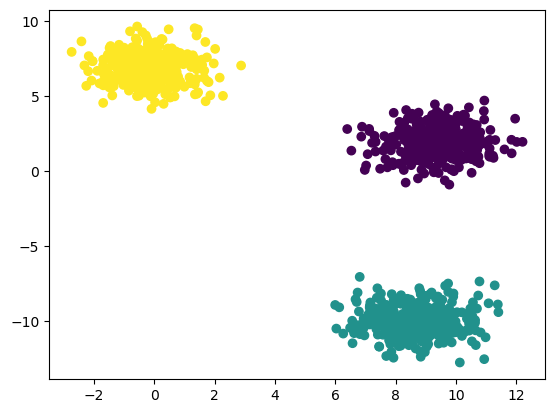

In [41]:
plt.scatter(x=X[:,0],y=X[:,1],c=y)

## Train-Test Split

The dataset is divided into training and testing sets.

Although clustering is an unsupervised learning technique, splitting helps simulate real-world workflows where the model is trained on one dataset and predictions are generated on unseen data.

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.33)

In [55]:
X_train.shape

(670, 2)

In [56]:
X_test.shape

(330, 2)

In [51]:
X_train

array([[  0.05138329,   7.89469934],
       [  9.44909371,  -9.98280165],
       [  8.76422442, -10.74017525],
       ...,
       [ 10.28487527,   2.39525291],
       [ 10.43549435, -10.63459252],
       [ 10.9356711 ,   3.42568106]], shape=(670, 2))

In [52]:
y_train

array([2, 1, 1, 1, 2, 1, 0, 0, 2, 1, 2, 0, 0, 1, 2, 2, 2, 2, 0, 0, 1, 0,
       2, 1, 1, 1, 1, 2, 2, 1, 0, 0, 1, 0, 2, 1, 2, 0, 0, 1, 0, 1, 1, 2,
       1, 1, 2, 2, 0, 2, 1, 0, 2, 1, 1, 1, 0, 2, 2, 2, 2, 0, 2, 1, 0, 2,
       2, 1, 2, 2, 1, 0, 2, 0, 2, 0, 0, 0, 2, 1, 1, 0, 2, 1, 0, 0, 0, 1,
       2, 1, 2, 1, 2, 0, 2, 2, 2, 2, 0, 0, 0, 1, 0, 2, 1, 1, 2, 1, 2, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 2, 1, 1, 1, 0, 0, 2, 0, 0, 2, 1, 2, 2, 2,
       0, 0, 1, 0, 1, 0, 2, 2, 1, 2, 0, 2, 2, 1, 1, 0, 2, 2, 1, 0, 0, 2,
       1, 0, 1, 1, 0, 2, 2, 2, 1, 2, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 2, 1,
       0, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 0, 1, 0, 0, 2,
       1, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 2, 1, 0, 2, 2, 0, 0, 0, 2, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1,
       1, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 0, 2, 1, 1, 1, 2, 2, 2, 1, 2,
       2, 2, 1, 1, 0, 2, 1, 2, 2, 2, 1, 2, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 2, 2, 0, 0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1,

In [53]:
X_test

array([[  9.35106952,   0.93177656],
       [ -0.49815929,   7.7600079 ],
       [ -0.32558571,   5.56221073],
       [  0.02673684,   5.9475583 ],
       [  0.34884844,   6.06152345],
       [  9.41119891,   1.72968814],
       [  9.4075663 ,   1.12147784],
       [  8.59087012,   1.46939052],
       [  8.66089737,   2.45994885],
       [ 10.54021902,  -9.65683059],
       [  1.70431259,   4.64285966],
       [  8.92370071,   0.74611457],
       [  7.21985792,   1.87439288],
       [  7.76585068,   2.08730142],
       [  7.40934739, -10.90254419],
       [ 10.2561429 ,   1.83085486],
       [  9.7662051 ,  -9.15314551],
       [  7.93353329, -10.52459237],
       [  9.57407916,   2.90096094],
       [  8.99374024,   1.41000782],
       [  8.16841456,  -8.84607871],
       [  8.27089303,   0.06314079],
       [  8.80100379,   2.2275864 ],
       [ -0.80013417,   9.30475261],
       [ 10.74293952,   0.95319427],
       [ 10.63469945,   1.16578896],
       [  6.56064881,  -9.97788341],
 

y_test

## Feature Scaling

Standardization is performed using `StandardScaler`.

K-Means uses Euclidean distance to form clusters, so scaling ensures all features contribute equally to distance calculations.

In [3]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [50]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [49]:
y_train

array([2, 1, 1, 1, 2, 1, 0, 0, 2, 1, 2, 0, 0, 1, 2, 2, 2, 2, 0, 0, 1, 0,
       2, 1, 1, 1, 1, 2, 2, 1, 0, 0, 1, 0, 2, 1, 2, 0, 0, 1, 0, 1, 1, 2,
       1, 1, 2, 2, 0, 2, 1, 0, 2, 1, 1, 1, 0, 2, 2, 2, 2, 0, 2, 1, 0, 2,
       2, 1, 2, 2, 1, 0, 2, 0, 2, 0, 0, 0, 2, 1, 1, 0, 2, 1, 0, 0, 0, 1,
       2, 1, 2, 1, 2, 0, 2, 2, 2, 2, 0, 0, 0, 1, 0, 2, 1, 1, 2, 1, 2, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 2, 1, 1, 1, 0, 0, 2, 0, 0, 2, 1, 2, 2, 2,
       0, 0, 1, 0, 1, 0, 2, 2, 1, 2, 0, 2, 2, 1, 1, 0, 2, 2, 1, 0, 0, 2,
       1, 0, 1, 1, 0, 2, 2, 2, 1, 2, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 2, 1,
       0, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 0, 1, 0, 0, 2,
       1, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 2, 1, 0, 2, 2, 0, 0, 0, 2, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1,
       1, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 0, 2, 1, 1, 1, 2, 2, 2, 1, 2,
       2, 2, 1, 1, 0, 2, 1, 2, 2, 2, 1, 2, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 2, 2, 0, 0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1,

In [58]:
from sklearn.cluster import KMeans

## Finding Optimal Number of Clusters using Elbow Method

The Elbow Method is used to determine the optimal number of clusters (K).

WCSS (Within-Cluster Sum of Squares) measures how compact the clusters are.

As K increases:
- WCSS decreases
- Improvement eventually slows down

The "elbow point" indicates the optimal K value.

In [61]:
#find k using elbow
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [62]:
wcss

[1340.0,
 353.26512309063094,
 44.80204549988346,
 38.34623819948819,
 31.76971564166842,
 24.446770876180995,
 22.624792452636896,
 20.69816079126271,
 18.632361352945583,
 17.189650434807973]

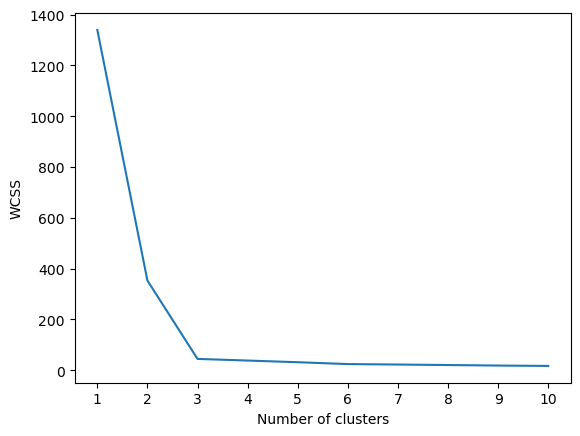

In [65]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## K-Means Clustering

K-Means clustering partitions the dataset into K clusters by:
1. Randomly initializing centroids
2. Assigning points to nearest centroid
3. Updating centroids using cluster mean
4. Repeating until convergence

Parameters used:
- n_clusters = 3
- init = k-means++

`k-means++` improves centroid initialization and reduces convergence issues.

In [66]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [69]:
y_pred=kmeans.fit_predict(X_test_scaled)

In [70]:
y_pred

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0,
       0, 1, 0, 0, 2, 2, 2, 2, 0, 1, 2, 1, 1, 2, 1, 0, 0, 0, 2, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1,
       2, 2, 1, 2, 0, 1, 0, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 0, 2, 2, 0, 2,
       0, 1, 2, 2, 2, 2, 1, 0, 1, 2, 0, 1, 0, 1, 2, 1, 0, 2, 0, 0, 2, 2,
       1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 2, 1, 2, 0, 0,
       2, 0, 2, 0, 2, 0, 0, 0, 1, 2, 2, 1, 2, 2, 1, 0, 2, 1, 2, 1, 2, 0,
       0, 0, 2, 0, 0, 2, 0, 2, 1, 2, 0, 2, 2, 2, 2, 1, 1, 0, 2, 2, 1, 1,
       0, 1, 1, 2, 1, 2, 2, 2, 2, 0, 0, 1, 0, 2, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 0, 2, 2, 2, 2, 2, 1, 2, 0, 2, 0,
       2, 1, 2, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2, 0, 2, 1, 2, 0, 1, 0,
       0, 0, 2, 1, 2, 0, 0, 0, 1, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 0, 1,
       0, 0, 0, 2, 1, 1, 0, 2, 2, 0, 1, 2, 0, 1, 1, 0, 1, 0, 0, 2, 2, 0,
       1, 0, 1, 2, 2, 2, 0, 2, 0, 1, 2, 1, 0, 2, 1,

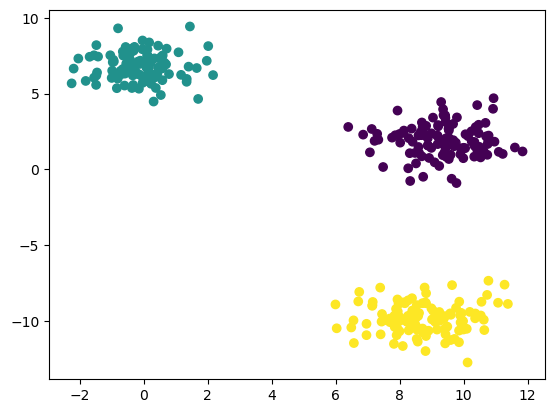

In [71]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [75]:
#kneeLocator - automating elbow detection
!pip install kneed

## Automated Elbow Detection using KneeLocator

`KneeLocator` is used to automatically identify the elbow point from the WCSS curve.

This reduces manual interpretation and confirms the optimal cluster count programmatically.

In [78]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')


In [83]:
kl.elbow
#kl.knee

np.int64(3)

Above we can see the value we used manually matches with the automated elbow etection 

## Cluster Validation using Silhouette Score

Silhouette Score evaluates cluster quality by measuring:
- Cohesion → how close points are within a cluster
- Separation → how distinct clusters are from each other

Interpretation:
- Close to +1 → strong clustering
- Around 0 → overlapping clusters
- Negative → poor clustering

The score is calculated for cluster values from 2 to 10.

In [85]:
from sklearn.metrics import silhouette_score

In [86]:
silhouette_coefficient=[]
for i in range(2,11):
    kmeans=KMeans(n_clusters=i,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficient.append(score)

In [87]:
silhouette_coefficient

[0.7015973728229055,
 0.8253630156765388,
 0.687988624770455,
 0.6696468835722917,
 0.5044137023462031,
 0.3711504058722879,
 0.35144743970206643,
 0.30448340949873787,
 0.34710962569031756]

## Conclusion

K-Means clustering successfully identified the underlying cluster structure in the dataset.

Key observations:
- The Elbow Method suggested an optimal cluster count of 3
- KneeLocator automatically confirmed K = 3
- Silhouette score showed strong cluster separation
- Feature scaling improved clustering performance

This notebook demonstrates a complete clustering workflow including preprocessing, model training, cluster optimization, visualization, and validation.